=== BENCHMARK EVALUATION RESULTS ===


,prompt_id,domain,has_hallucination,error_type,similarity_score
0,prompt_001,Target Identification & Molecular Assays,True,Protocol Logic & Normalization Flaw,0.1084
1,prompt_002,Genomic Workflow & RNA-Seq,False,None,0.3112
2,prompt_003,Protein Kinetics & Enzymology,True,Inverted Biological Definition,0.1092


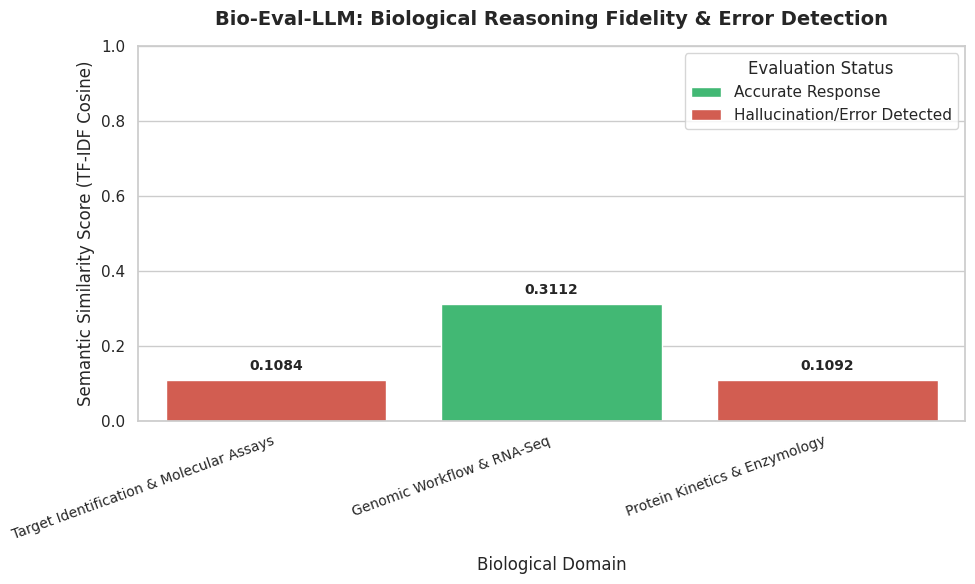


--- BENCHMARK SUMMARY REPORT ---
Total Evaluated Prompts : 3
Hallucination Rate      : 66.7% (2/3 failed)
Average Similarity Score: 0.1763


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Set aesthetic styling for plots
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# ---------------------------------------------------------
# 1. Load Synthetic Evaluation Dataset
# ---------------------------------------------------------
dataset_path = '../data/eval_dataset.json'

with open(dataset_path, 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)

# ---------------------------------------------------------
# 2. Natural Language Processing & Similarity Scoring
# ---------------------------------------------------------
vectorizer = TfidfVectorizer()
similarity_scores = []

for _, row in df.iterrows():
    # Fit vectorizer on paired Ground Truth and AI Response text
    tfidf_matrix = vectorizer.fit_transform([row['ground_truth_logic'], row['ai_response']])
    # Compute Cosine Similarity between the two vectors
    sim = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
    similarity_scores.append(round(float(sim), 4))

df['similarity_score'] = similarity_scores

# Display formatted evaluation dataframe
print("=== BENCHMARK EVALUATION RESULTS ===")
display(df[['prompt_id', 'domain', 'has_hallucination', 'error_type', 'similarity_score']])

# ---------------------------------------------------------
# 3. Visualization: Domain Semantic Fidelity & Hallucinations
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plot bar chart comparing semantic similarity scores across biological domains
ax = sns.barplot(
    data=df, 
    x='domain', 
    y='similarity_score', 
    hue='has_hallucination',
    palette={True: '#e74c3c', False: '#2ecc71'}, # Red for Hallucinations, Green for Accurate
    dodge=False
)

# Customizing plot annotations and titles
plt.title('Bio-Eval-LLM: Biological Reasoning Fidelity & Error Detection', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Biological Domain', fontsize=12, labelpad=10)
plt.ylabel('Semantic Similarity Score (TF-IDF Cosine)', fontsize=12)
plt.ylim(0, 1.0)
plt.xticks(rotation=20, ha='right', fontsize=10)

# Add Legend labels
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=['Accurate Response', 'Hallucination/Error Detected'], title='Evaluation Status', loc='upper right')

# Annotate exact similarity values on top of bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{height:.4f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold',
                    xytext=(0, 5),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Summary Metrics
# ---------------------------------------------------------
total_prompts = len(df)
hallucination_count = df['has_hallucination'].sum()
hallucination_rate = (hallucination_count / total_prompts) * 100
avg_similarity = df['similarity_score'].mean()

print("\n--- BENCHMARK SUMMARY REPORT ---")
print(f"Total Evaluated Prompts : {total_prompts}")
print(f"Hallucination Rate      : {hallucination_rate:.1f}% ({hallucination_count}/{total_prompts} failed)")
print(f"Average Similarity Score: {avg_similarity:.4f}")